# Data Cleaning & Preprocessing Assignment

Name: Mohammad Hasibur Rahman
Batch: AI & ML Engineering Bootcamp (Batch 1)
Date: 14 June 2026

Dataset: dirty_dataset.csv

Objective:
Clean and preprocess a dirty dataset by identifying and fixing common data quality issues.

# Importing all libraries we need

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from pandas.core.dtypes.cast import infer_dtype_from_array  # this came auto while writing code
from imblearn.over_sampling import RandomOverSampler # this also

# Reading and storing all values from csv file

In [ ]:
df = pd.read_csv("dirty_dataset.csv")
df_clean = df.copy() # function to copy dataset

### Dataset Overview

- `df.head()` displays the first few rows of the dataset and helps us inspect the data structure.
- `df.info()` provides information about data types, non-null counts, and memory usage.
- `df.describe(include='all')` generates descriptive statistics for both numerical and categorical columns.

In [3]:
df.head()

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
1,7361,Grace P.,NaN,77836,2017-02-27,Engineering,FEMALE,America,Chittagong,71kg,True,Product met all expectations.,329.26,NaN,0
2,3446,Eve D.,20.0,35404,2022-01-18,hr,male,BANGLADESH,Chitagong,98.7,False,Very satisfied with the quality.,438.6,NaN,0
3,18416,Diana E.,47.0,107375,2017-04-15,Marketing,Male,U.K.,Khulna,NaN,false,Delivery was fast and packaging great.,238.03,NaN,0
4,13677,Ira W.,64.0,55962,2021-11-02,SALES,F,United Kingdom,Dhaka,83.5,false,Would buy again without hesitation.,9.4,NaN,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20300 entries, 0 to 20299
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          20300 non-null  int64  
 1   name                 20300 non-null  str    
 2   age                  19679 non-null  float64
 3   salary               19690 non-null  str    
 4   join_date            19490 non-null  str    
 5   department           19443 non-null  str    
 6   gender               18668 non-null  str    
 7   country              19692 non-null  str    
 8   city                 19696 non-null  str    
 9   weight_kg            19657 non-null  str    
 10  is_active            19714 non-null  str    
 11  review               18835 non-null  str    
 12  price                19854 non-null  str    
 13  weight_kg_duplicate  0 non-null      float64
 14  target               20300 non-null  int64  
dtypes: float64(2), int64(2), str(11)
memory usage: 

In [5]:
df.describe(include="all")

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
count,20300.000000,20300,19679.000000,19690,19490,19443,18668,19692,19696,19657,19714,18835,19854,0.0,20300.000000
unique,NaN,260,NaN,17213,7579,10,10,13,11,922,8,15,16460,NaN,NaN
top,NaN,Bob I.,NaN,9999999,2023-06-09,Sales,M,USA,Khulna,96kg,True,Delivery was fast and packaging great.,-459,NaN,NaN
freq,NaN,101,NaN,318,15,1995,1951,1550,3815,38,7446,2834,6,NaN,NaN
mean,9903.786305,NaN,45.457696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.049655
std,5822.475853,NaN,63.075321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.217237
min,1.000000,NaN,-5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4850.750000,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,9908.500000,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,14944.250000,NaN,54.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


## Task 01: Missing Values (NaN, Empty Strings)

### Problem Description

Missing values are common data quality issues that can affect data analysis and machine learning models. In this task, we identify missing values such as NaN and empty strings and handle them using appropriate techniques.
* The dataset contains missing values in multiple columns. According to the assignment instructions, missing values in numerical columns should be filled using the median value. However, some numerical columns such as salary, price, and weight_kg are currently stored as strings and must be converted to numeric format before median imputation.

In [ ]:
# df_clean.isnull().sum()
# df_clean[["age", "salary", "price", "weight_kg"]].dtypes ## It is used to check the datatypes of that columns value

# Handling age immediately since it is already numeric
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# df_clean["salary"] = (
#     df_clean["salary"]
#     .astype(str)
#     .str.replace("$", "", regex=False) # this is not universal, only works for $ sign, so making universal type
# )
# df_clean["salary"] = pd.to_numeric(df_clean["salary"], errors="coerce")

# Convert mixed numeric text into proper numeric values
def clean_numeric_column(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r"[^0-9.-]", "", regex=True),
        errors="coerce"
    )

df_clean["salary"] = clean_numeric_column(df_clean["salary"])
df_clean["price"] = clean_numeric_column(df_clean["price"])
df_clean["weight_kg"] = clean_numeric_column(df_clean["weight_kg"])

# df_clean[["salary", "price", "weight_kg"]].dtypes # now all are numeric

numeric_cols = ["age", "salary", "price", "weight_kg"]

# Fill missing numeric values with median
df_clean[numeric_cols] = (
    df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
)

categorical_col = ["department", "gender", "country", "city"]

# Fill categorical missing values using most frequent value
df_clean[categorical_col] = (
    df_clean[categorical_col].fillna(df_clean[categorical_col].mode().iloc[0])
)  # iloc[0] for whole dataframe, if only one series, then it would be mode()[0]

# forward fill
df_clean["join_date"] = df_clean["join_date"].ffill()

# most freq fill
# df_clean["join_date"] = df_clean["join_date"].fillna(
#     df_clean["join_date"].mode()[0]
# )

# Standardize missing reviews
df_clean["review"] = df_clean["review"].fillna("No Review")

# Missing status values are treated as inactive
df_clean["is_active"] = df_clean["is_active"].fillna(False)

## weight_kg_duplicate is still full of NaN ,, though in this task, it is not said to touch it, I am keeping it untouched, in future , I will handle it in another task

# Final verification
df_clean.isnull().sum()

employee_id                0
name                       0
age                        0
salary                     0
join_date                  0
department                 0
gender                     0
country                    0
city                       0
weight_kg                  0
is_active                  0
review                     0
price                      0
weight_kg_duplicate    20300
target                     0
dtype: int64

### Task 01 Explanation

The first step in the data cleaning process was identifying missing values using `df_clean.isnull().sum()`. This allowed us to see how many missing records were present in each column and determine the most appropriate strategy for handling them.

The `age` column was already stored as a numeric data type, so its missing values were replaced using the median of the column. The median was chosen because it is less sensitive to extreme values and outliers than the mean, making it a more reliable measure for numerical imputation.

The `salary`, `price`, and `weight_kg` columns contained numerical information stored as text. Before handling missing values, these columns were converted into proper numeric format. Instead of removing only specific symbols such as `$` or `kg`, a regular expression was used to keep only digits, decimal points and negative signs. This approach is more robust because it can handle unexpected symbols, currency formats, units, and other noisy text values. Any invalid values that could not be interpreted as numbers were automatically converted to `NaN` using `pd.to_numeric(..., errors="coerce")`.

After converting the columns to numeric format, the missing values in `age`, `salary`, `price`, and `weight_kg` were filled using their respective median values. This ensured that all numerical columns remained usable for further analysis while minimizing distortion of the underlying data distribution.

The categorical columns (`department`, `gender`, `country`, and `city`) were cleaned using mode imputation. The mode represents the most frequently occurring value in a column and is commonly used for handling missing values in categorical data because it preserves the most representative category. Since multiple columns were processed simultaneously as a DataFrame, `mode().iloc[0]` was used to obtain the first row of mode values for all categorical columns.

For the `join_date` column, missing values were handled using forward fill (`ffill`). This method propagates the most recent valid date downward and is often appropriate for sequential or time-related data, helping preserve continuity in the dataset.

The `review` column contained missing textual feedback. These missing values were replaced with the placeholder value `"No Review"` so that the absence of a review is explicitly represented instead of remaining missing.

The `is_active` column was treated using a conservative approach. Missing values were replaced with `False`, assuming inactivity when no reliable information was available. This is generally safer than assuming an active status without supporting evidence.

One additional column, `weight_kg_duplicate`, still contains missing values. This column was intentionally left unchanged during Task 01 because it was not listed among the affected columns in the assignment requirements. The column will be evaluated and handled separately in a later task if necessary.

After completing these steps, all required columns specified in Task 01 were successfully cleaned and their missing values were appropriately handled according to the assignment guidelines.


## Task 2 : Duplicate Rows
* Duplicate rows means the rows which ar exactly same with some other rows, if 5 rows are same, only 1st row is considered as real and the rests are considered as duplicate rows

In [27]:
# Count total duplicate rows
df_clean.duplicated().sum()

df_clean.shape  # shape before (20300, 15)

# Preview duplicate records
df_clean[df_clean.duplicated()]

# Remove duplicate rows
df_clean.drop_duplicates(inplace=True)

# Verify dataset size after removing duplicates
df_clean.shape  # shape after (20009, 15)

(19801, 14)

## Task 02 Explanation
First, I used `df_clean.duplicated().sum()` to count the total number of duplicate rows in the dataset. The result showed that there were 291 fully duplicated records.

Next, I checked the dataset shape before cleaning using `df_clean.shape`, which returned `(20300, 15)`. This means the dataset initially contained 20,300 rows and 15 columns.

To better understand the duplicated data, I displayed all duplicate rows using `df_clean[df_clean.duplicated()]`. This allowed me to preview the redundant records before removing them.

I then applied `df_clean.drop_duplicates(inplace=True)` to remove all exact duplicate rows while keeping the first occurrence of each record.

Finally, I checked the dataset shape again using `df_clean.shape`. The shape changed from `(20300, 15)` to `(20009, 15)`, confirming that 291 duplicate rows were successfully removed.

Removing duplicate records improves data quality, prevents repeated observations from influencing analysis, and ensures that each row in the dataset represents a unique observation.

Duplicate rows can negatively impact statistical analysis, visualization, and machine learning models by giving certain observations more weight than intended. Therefore, removing duplicates is an important preprocessing step.

## Task 03: Duplicate IDs

The `employee_id` column contains approximately 499 duplicate values, even though employee IDs should be unique for each employee.

In this task, duplicate employee IDs will be identified and examined. Appropriate cleaning techniques will then be applied to ensure data consistency and maintain the integrity of employee records.

In [28]:
# Count duplicate employee IDs
df_clean["employee_id"].duplicated().sum()

# Preview all duplicate employee IDs
df_clean[df_clean["employee_id"].duplicated(keep=False)]

print("Before:", df_clean.shape)

# Remove duplicate employee IDs, keeping the first occurrence
df_clean.drop_duplicates(
    subset=["employee_id"], keep="first", inplace=True
)

# Verifying no duplicate employee IDs remain
assert df_clean["employee_id"].duplicated().sum() == 0

df_clean["employee_id"].duplicated().sum()

# Check dataset shape after cleaning
print("After :", df_clean.shape)

Before: (19801, 14)
After : (19801, 14)


## Task 03 Explanation

The `employee_id` column should contain a unique identifier for each employee. After completing the previous cleaning tasks, I found that 208 duplicate employee IDs still existed in the dataset.

To investigate the issue, I first counted the duplicate IDs and reviewed the affected records. Since each employee should have only one unique ID, duplicate IDs can cause inaccurate employee counts, data integrity problems, and unreliable analytical results.

Following the assignment instructions, I used `drop_duplicates()` with the `subset=['employee_id']` parameter to remove duplicate employee IDs while keeping the first occurrence of each employee record.

The parameter `keep='first'` ensures that the first appearance of an employee ID is preserved and all subsequent duplicate occurrences are removed.

Finally, I verified the result using:

`df_clean["employee_id"].duplicated().sum()`

and also used an assertion statement:

`assert df_clean["employee_id"].duplicated().sum() == 0`

to confirm that no duplicate employee IDs remained in the dataset.

This step improves data consistency and guarantees that each employee is represented by a single unique identifier.

## Task 04: Wrong Date Formats

The `join_date` column contains dates stored in different formats, which can create inconsistencies and make date-based analysis difficult.

In this task, the date values will be standardized into a consistent format to improve data quality and ensure accurate processing of date information.

In [ ]:
# Check current data type
df_clean["join_date"].dtype

# Convert mixed date formats into proper datetime values
df_clean["join_date"] = pd.to_datetime(
    df_clean["join_date"],
    errors="coerce"
)  # infer_datetime_format=True was not working on my python version, so removed

# Fill invalid/missing dates with the median date
df_clean["join_date"] = df_clean["join_date"].fillna(
    df_clean["join_date"].median()
)

df_clean["join_date"]

# df_clean["join_date"].isna().sum()

# Standardize date format
df_clean["join_date"] = df_clean["join_date"].dt.strftime("%Y-%m-%d")

# This converts the column to string, so convert it back to datetime
df_clean["join_date"] = pd.to_datetime(df_clean["join_date"])

# Verify final data type
df_clean["join_date"].dtype

dtype('<M8[us]')

## Task 04 Explanation

The `join_date` column contained dates stored in multiple formats, making the data inconsistent and difficult to analyze. Therefore, the column needed to be converted into a standard datetime format.

First, I checked the data type of the `join_date` column using `df_clean["join_date"].dtype`. The column was stored as a string type rather than a datetime type.

Next, I used `pd.to_datetime()` with `errors="coerce"` to convert all date values into datetime format. The `errors="coerce"` parameter ensures that any invalid or unrecognized date values are converted to `NaT` (Not a Time) instead of causing an error. The `infer_datetime_format` parameter mentioned in the assignment was not available in my pandas version, so I omitted it.

After the conversion, any missing or invalid dates were filled using the median date value of the column:

`df_clean["join_date"].fillna(df_clean["join_date"].median())`

Using the median date is a reasonable choice because it represents the central date in the dataset and prevents missing values from affecting future analysis.

To standardize the appearance of all dates, I applied:

`df_clean["join_date"].dt.strftime("%Y-%m-%d")`

This converted every date into the consistent `YYYY-MM-DD` format. However, `strftime()` returns string values, which changes the column's data type from datetime to string.

To preserve the benefits of datetime operations while keeping the standardized format, I converted the column back to datetime using:

`pd.to_datetime(df_clean["join_date"])`

Finally, I verified the data type again using:

`df_clean["join_date"].dtype`

The result confirmed that the column was successfully stored as a datetime type, and all date values now follow a consistent format suitable for analysis and machine learning tasks.

## Task 05: Numeric Values Stored as Strings

The `salary`, `weight_kg`, and `price` columns contain numeric values mixed with symbols or text such as `$` and `kg`. As a result, these columns are stored as strings instead of numeric data types.

In this task, the unnecessary characters will be removed and the columns will be converted into proper numeric formats for accurate analysis and computation.

In [ ]:
# Check current data types
df_clean["salary"].dtype
df_clean["weight_kg"].dtype
df_clean["price"].dtype

# These columns were already cleaned in Task 01.
# Example approaches mentioned in the assignment:

# Salary
# df_clean["salary"] = (
#     df_clean["salary"]
#     .astype(str)
#     .str.replace("$", "", regex=False)
#     .astype(float)
# )

# Weight
# df_clean["weight_kg"] = (
#     df_clean["weight_kg"]
#     .astype(str)
#     .str.replace("kg", "", regex=False)
#     .astype(float)
# )

# Price
# df_clean["price"] = (
#     df_clean["price"]
#     .astype(str)
#     .str.replace("$", "", regex=False)
#     .astype(float)
# )

# More robust approach
# pd.to_numeric(df_clean["salary"], errors="coerce")
# pd.to_numeric(df_clean["weight_kg"], errors="coerce")
# pd.to_numeric(df_clean["price"], errors="coerce")

# Direct pd.to_numeric() would convert values like "$5000"
# or "70kg" into NaN unless symbols/text are removed first.

# Verify final data types
df_clean[["salary", "weight_kg", "price"]].dtypes

salary       float64
weight_kg    float64
price        float64
dtype: object

## Task 05 Explanation

The `salary`, `weight_kg`, and `price` columns contained numeric values mixed with symbols and units such as `$` and `kg`. Because of these extra characters, the values could not be reliably treated as numerical data.

During Task 01, I cleaned these columns using a regular expression that removes all characters except digits (`0-9`), decimal points (`.`), and negative signs (`-`). This approach is more flexible than removing specific symbols one by one because it can handle a wider variety of unexpected characters.

After removing the non-numeric characters, I used `pd.to_numeric()` with `errors="coerce"` to convert the values into numeric format. The `errors="coerce"` parameter ensures that any invalid values are safely converted to `NaN` instead of causing an error.

Finally, I verified the data types and confirmed that the `salary`, `weight_kg`, and `price` columns are stored as numeric (`float64`) values. This makes the data suitable for calculations, statistical analysis, visualization, and machine learning tasks.

## Task 06: Inconsistent Labels

Several categorical columns contain inconsistent labels that represent the same category but are written in different formats. For example, the `country` column contains values such as `USA`, `U.S.A`, `us`, and `America`, while the `gender` and `department` columns also contain variations in capitalization, spelling, and formatting.

These inconsistencies can create duplicate categories, produce inaccurate summaries, and negatively affect data analysis and machine learning models.

The objective of this task is to standardize the labels by converting equivalent values into a single consistent representation, ensuring that each category is stored in a uniform format throughout the dataset.

In [ ]:
# Check category distributions before cleaning
df_clean["country"].value_counts()
df_clean["gender"].value_counts()
df_clean["department"].value_counts()

# Standardizing country labels

country_map = {
    "USA": "United States",
    "usa": "United States",
    "U.S.A": "United States",
    "us": "United States",
    "America": "United States",

    "UK": "United Kingdom",
    "U.K.": "United Kingdom",

    "BD": "Bangladesh",
    "bd": "Bangladesh",
    "BANGLADESH": "Bangladesh"
}

# Map inconsistent country names to a standard label
df_clean["country"] = (
    df_clean["country"].map(country_map).fillna(df_clean["country"])
)

# alternative way
# df_clean["country"] = (
#     df_clean["country"].replace(country_map)
# )

# Standardizing gender labels

# Remove extra spaces and make values lowercase
df_clean["gender"] = (
    df_clean["gender"].str.strip().str.lower()
)

gender_map = {
    "m": "Male",
    "male": "Male",
    "man": "Male",

    "f": "Female",
    "female": "Female",
    "woman": "Female"
}

# Convert different gender representations into standard labels
df_clean["gender"] = (
    df_clean["gender"].map(gender_map).fillna(df_clean["gender"])
)

# alternative way
# df_clean["gender"] = df_clean["gender"].replace(gender_map)

# Standardizing department labels

# Remove spaces and standardize text formatting
df_clean["department"] = (
    df_clean["department"].str.strip().str.title()
)

department_map = {
    "Hr": "HR",
    "Mrketing": "Marketing",
    "Finace": "Finance"
}

# Fix misspelled department names
df_clean["department"] = (
    df_clean["department"].map(department_map).fillna(df_clean["department"])
)

# alternative way
# df_clean["department"] = df_clean["department"].replace(department_map)

# Verification

df_clean["country"].value_counts()

df_clean["gender"].value_counts()

df_clean["department"].value_counts()

department
Sales          4649
HR             3805
Engineering    3794
Marketing      3788
Finance        3765
Name: count, dtype: int64

## Task 06 Explanation

The `country`, `gender`, and `department` columns contained inconsistent labels that represented the same categories but were written in different formats. These inconsistencies included differences in capitalization, abbreviations, spelling mistakes, and naming conventions.

First, I inspected the unique values in each column using `value_counts()` to identify the inconsistent labels that needed to be standardized.

For the `country` column, I created a mapping dictionary (`country_map`) and converted different representations of the same country into a single standard label. For example, `USA`, `usa`, `U.S.A`, `us`, and `America` were all converted to `United States`. Similarly, `UK` and `U.K.` were standardized to `United Kingdom`, while `BD`, `bd`, and `BANGLADESH` were standardized to `Bangladesh`.

To apply these changes, I used:

`map(country_map).fillna(df_clean["country"])`

The `map()` function replaces values that exist in the dictionary, while `fillna()` keeps the original value when no matching key is found.

For the `gender` column, I first removed unnecessary spaces using `str.strip()` and converted all values to lowercase using `str.lower()`. This ensured that labels such as `Male`, `MALE`, and `male` were treated consistently. I then mapped equivalent labels such as `m`, `male`, and `man` to `Male`, and `f`, `female`, and `woman` to `Female`.

For the `department` column, I removed extra spaces using `str.strip()` and standardized capitalization using `str.title()`. The `title()` method converts the first letter of each word to uppercase and the remaining letters to lowercase. After that, I corrected spelling mistakes and formatting issues such as `Hr` → `HR`, `Mrketing` → `Marketing`, and `Finace` → `Finance`.

Finally, I verified the results using `value_counts()` on all three columns. The number of duplicate category labels was reduced, and each category was stored in a consistent format.

Standardizing categorical labels improves data quality, prevents the same category from being counted multiple times, and produces more accurate analysis and machine learning results.

## Task 07 Spelling Mistakes

It includes some columns with wrong spellings like city, department etc. We have to identify those words and need to fix them correctly..

In [ ]:
# Check city values before cleaning
df_clean["city"].value_counts()

# Fix inconsistent city names
city_fix = {
    "Dhka": "Dhaka",
    "Dhakka": "Dhaka",
    "Rajshai": "Rajshahi",
    "Slyhet": "Sylhet",
    "Chittagongg": "Chittagong",
    "Chitagong": "Chittagong"
}

df_clean["city"] = df_clean["city"].replace(city_fix)

# df_clean["city"].value_counts() # now fixed all

# Check department values before cleaning
df_clean["department"].value_counts()

# Fix misspelled department names
dept_fix = {
    "Mrketing": "Marketing",
    "Finace": "Finance",
}

df_clean["department"] = df_clean["department"].replace(dept_fix)

# df_clean["department"].value_counts()

# Verify unique values after cleaning
df_clean["city"].unique()
df_clean["department"].unique()

<StringArray>
['Sales', 'Engineering', 'HR', 'Marketing', 'Finance']
Length: 5, dtype: str

## Task 07 Explanation

As we can see by using 'df_clean["city"].value_counts()' that there are some misspelled words in the city column. So, to fix that column, at first we made a dictionary named 'city_fix' and kept the misspelled words as key and the fixed words as value. And then we mapped the misspelled words with the corrected words by using 'df_clean["city"].replace(city_fix)'.

Similarly, there are some misspelled words in the 'department' column. So, to fix that column, at first we made a dictionary named 'dept_fix' and kept the misspelled words as key and the fixed words as value. And then we mapped the misspelled words with the corrected words by using 'df_clean["department"].replace(dept_fix)'.

At last, to verify the uniqueness, we used 'df_clean["city"].unique()' and
'df_clean["department"].unique()' which gives us the values and we can see that there is no misspelled word and all are unique.

## Task 08: Outliers

The `salary` column contains extreme values that are significantly different from the rest of the data. These outliers can distort statistical measures such as the mean and negatively affect data analysis and machine learning models.

The objective of this task is to identify salary outliers using the IQR method and reduce their impact by capping them within an acceptable range.

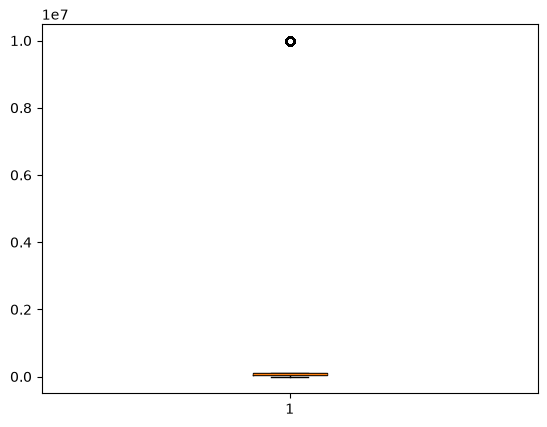

In [ ]:
# Check min, max, mean and quartiles
df_clean["salary"].describe()

# Box plot helps identify potential outliers
plt.boxplot(df_clean["salary"])
plt.show()

In [ ]:
# Q1 = 25th percentile, Q3 = 75th percentile
Q1 = df_clean["salary"].quantile(0.25)
Q3 = df_clean["salary"].quantile(0.75)

# Distance between Q1 and Q3
IQR = Q3 - Q1

# Values outside these bounds are treated as outliers
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-14404.0
163212.0


In [ ]:
# Preview rows containing salary outliers
df_clean[
    (df_clean["salary"] < lower) |
    (df_clean["salary"] > upper)
]

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
48,13959,John H.,41.0,9999999.0,2022-11-22,Marketing,Male,United States,Dhaka,55.2,False,Good value for money.,-187.00,NaN,0
184,9145,Ira D.,33.0,9999999.0,2014-04-13,Finance,Male,United States,Sylhet,80.8,True,Product met all expectations.,91.95,NaN,0
241,10482,Grace S.,40.0,9999999.0,2017-02-27,HR,Male,Bangladesh,Sylhet,119.5,False,Product met all expectations.,102.90,NaN,0
285,11357,Hasan U.,35.0,9999999.0,2024-12-07,HR,Male,Bangladesh,Rajshahi,99.4,False,Would buy again without hesitation.,261.08,NaN,0
318,11589,Grace D.,63.0,9999999.0,2015-03-02,Finance,Male,United States,Chittagong,109.0,True,"Excellent product, highly recommend!",170.97,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20195,2552,Ira D.,40.0,9999999.0,2022-09-20,Finance,Female,United States,Dhaka,124.3,True,Product met all expectations.,42.50,NaN,0
20249,4211,Eve H.,58.0,9999999.0,2017-07-12,Marketing,Female,United States,Khulna,100.8,True,Good value for money.,200.78,NaN,0
20256,9677,Charlie L.,41.0,9999999.0,2015-09-12,Engineering,Female,United States,Rajshahi,93.6,TRUE,Good value for money.,244.98,NaN,0
20284,17429,Frank F.,34.0,9999999.0,2017-07-12,Engineering,Female,United States,Khulna,86.8,False,No Review,216.29,NaN,1


In [16]:
df_clean["salary"] = df_clean["salary"].clip(lower, upper)
df_clean["salary"].describe()

count     19801.00000
mean      74922.48245
std       28692.61617
min        -500.00000
25%       52202.00000
50%       74404.50000
75%       96606.00000
max      163212.00000
Name: salary, dtype: float64

## Task 08 Explanation

The `salary` column contained extreme outlier values that could affect data analysis and model performance.

I first explored the column using `describe()` and visualized the distribution with a box plot. Then, I calculated the Interquartile Range (IQR) using the first quartile (Q1) and third quartile (Q3).

Using the IQR method, I determined the lower and upper bounds for valid salary values. Records outside these bounds were identified as outliers.

Instead of removing the records, I capped the outlier values using `clip()`. Values below the lower bound were replaced with the lower bound, and values above the upper bound were replaced with the upper bound.

Finally, I verified the results using `describe()` to confirm that the extreme salary values had been controlled while preserving the dataset size.

## Task 09 Invalid Values

In this task, we have some columns like age, price etc with some invalid values.
Invalid values means, like no price can be negative, if any price is negative then it is invalid. Also in the age column, age less than 18 and greater than 65 is also invalid in this case. So. we need to fix that values with correct predictions.

In [ ]:
# Define valid ranges
MIN_AGE = 18
MAX_AGE = 65
MIN_PRICE = 0

# Count invalid age values
df_clean[(df_clean['age'] < MIN_AGE) | (df_clean['age'] > MAX_AGE)].shape  #(388, 15)

# Replace out-of-range ages with NaN
df_clean.loc[df_clean['age'] < MIN_AGE, 'age'] = np.nan
df_clean.loc[df_clean['age'] > MAX_AGE, 'age'] = np.nan

# df_clean['age'].fillna(df['age'].median(), inplace=True) # Though it is correct, it is not working on my compiler, so removing inplace and storing back

# Fill missing ages with median age
df_clean["age"] = df_clean['age'].fillna(df['age'].median())

# Verify age values are now within range
df_clean[(df_clean['age'] < MIN_AGE) | (df_clean['age'] > MAX_AGE)].shape

# Count negative prices
df_clean[(df_clean['price'] < MIN_PRICE)].shape # (390, 15)

# Replace negative prices with NaN
df_clean.loc[df_clean['price'] < MIN_PRICE, 'price'] = np.nan

df_clean["price"].dtype

# Inspect data types before calculating median
print(df['price'].apply(type).value_counts())

# Convert mixed values into numeric format
df['price'] = pd.to_numeric(df['price'], errors='coerce') # converting all to numerics

# Fill missing prices with median price
df_clean['price'] = df_clean['price'].fillna(df['price'].median())

# Verify no negative prices remain
df_clean[(df_clean['price'] < MIN_PRICE)].shape # now (0, 15)

# Final verification
assert (df_clean["age"] >= MIN_AGE).all() and (df_clean["age"] <= MAX_AGE).all()

assert (df_clean["price"] >= MIN_PRICE).all()

price
<class 'str'>      19854
<class 'float'>      446
Name: count, dtype: int64


## Task 09 Explanation

The dataset contained unrealistic values in the `age` and `price` columns that could negatively affect analysis and machine learning models. Therefore, these values needed to be identified and corrected.

For the `age` column, I defined a valid range of 18 to 65 years. Any age value below 18 or above 65 was considered unrealistic and treated as an invalid entry. I first counted the affected records and found 388 rows containing out-of-range age values.

To clean the data, I replaced all invalid age values with `NaN` and then filled the missing values using the median age. The median was chosen because it is less sensitive to extreme values and provides a reliable central value for the dataset.

For the `price` column, I identified all negative values, since a product price cannot logically be negative. A total of 390 rows contained negative prices. These values were replaced with `NaN` and then filled using the median price value.

Before calculating the median price, I converted the column to numeric format using `pd.to_numeric(errors="coerce")` to ensure that all values could be processed correctly.

After cleaning both columns, I verified the results using assertion statements. The verification confirmed that:

- All age values are now within the valid range of 18 to 65.
- No negative price values remain in the dataset.

This process improves data quality by removing unrealistic values and replacing them with reasonable estimates, making the dataset more suitable for analysis, visualization, and machine learning applications.

## Task 10: Noisy Text (Reviews)

The `review` column contains noisy and low-quality text values such as `ok`, `bad`, `na`, `n/a`, `...`, `fine`, and other short or meaningless responses. These values provide little useful information and can negatively affect text analysis and machine learning models.

The objective of this task is to identify noisy review entries, replace them with missing values, and then fill them with a standardized label to improve data consistency and quality.

In [29]:
# Check review distribution before cleaning
df_clean["review"].value_counts()

# Define low-quality/noisy review values
noisy = ['ok', 'bad', 'n/a', '...', 'fine', 'not bad', 'ok ok', '.']

# Replace noisy reviews with NaN
df_clean['review'] = df_clean['review'].replace(noisy, np.nan)

# df_clean['review'].replace('', np.nan, inplace=True)

# Treat empty strings as missing values
df_clean["review"] = df_clean["review"].replace("", np.nan)

# Replace missing reviews with a standard label
df_clean['review'] = df_clean['review'].fillna('No Review')

# Verify cleaned review distribution
df_clean["review"].value_counts()

# Check the number of words in each review
df_clean['review'].str.split().str.len().value_counts()

review
4    8192
5    5393
2    2996
6    2768
1     452
Name: count, dtype: int64

## Task 10 Explanation

The dataset contained several noisy and low-quality entries in the `review` column. Examples included values such as `ok`, `bad`, `n/a`, `...`, `fine`, `not bad`, `ok ok`, and `.`. These reviews provide little meaningful information and can negatively affect text analysis and machine learning models.

To identify these values, I first inspected the review column using `value_counts()`. This allowed me to see the frequency of different review texts and detect common noisy entries.

After identifying the noisy values, I created a predefined list containing all such entries and replaced them with `NaN` (missing values). I also replaced any empty strings (`""`) with `NaN` to ensure that all missing or meaningless reviews were handled consistently.

Once the noisy and empty values were converted to missing values, I filled all `NaN` entries with the standardized label `"No Review"`. This approach preserves the records while clearly indicating that no useful review information is available.

To verify the results, I checked the review distribution again using `value_counts()`. I also analyzed the number of words in each review using:

'df_clean["review"].str.split().str.len().value_counts()'


This helped confirm that the noisy reviews had been removed and replaced appropriately.

After cleaning, the review column became more consistent and suitable for text analysis, visualization, and machine learning tasks. Replacing meaningless reviews with a standardized value improves overall data quality and makes the dataset easier to work with.

## Task 11 Boolean as String

The dataset contains inconsistent values in the `is_active` column. Instead of storing values as proper Boolean data types (`True` or `False`), the column contains a mixture of Boolean values and string representations such as `'True'`, `'False'`, `'true'`, `'false'`, `'1'`, and `'0'`.

This inconsistency can cause problems during filtering, aggregation, and machine learning tasks because values that represent the same meaning are stored in different formats.

The objective of this task is to standardize all values in the `is_active` column into a consistent Boolean format (`True` or `False`). To accomplish this, the unique values in the column are first inspected to identify all existing variations. Then, values representing an active state are mapped to `True`, while all other values are mapped to `False`.

After standardization, the column will contain only valid Boolean values, improving data consistency and making the dataset easier to analyze and process.

In [ ]:
# Check unique values before conversion
df_clean['is_active'].unique()

# Values that should be treated as True
true_vals = ['True', 'true', 'TRUE', '1', True, 1]

# Convert different True representations into boolean values
df_clean['is_active'] = df_clean['is_active'].isin(true_vals)

# Verify cleaned values
df_clean['is_active'].unique()

# Alternative approach using lambda
df_clean['is_active'] = df_clean['is_active'].map(
    lambda x: str(x).lower() in ['true', '1']
)

# Check final data type
df_clean['is_active'].dtype

dtype('bool')

## Task 11 Explanation

The `is_active` column contained inconsistent Boolean values. Instead of storing values in a single format, the column included different representations such as `'True'`, `'true'`, `'TRUE'`, `'1'`, `True`, `1`, as well as their false equivalents.

This inconsistency can create problems during filtering, grouping, and analysis because values representing the same meaning are stored in different formats.

To identify the different variations, I first inspected the column using `unique()`. After reviewing the unique values, I created a list named `true_vals` containing all values that should be considered as `True`.

Using the `isin()` function, I checked whether each value belonged to the `true_vals` list. If a value was found in the list, it was converted to `True`; otherwise, it was converted to `False`. This standardized the entire column into a proper Boolean format.

As an alternative approach, the same result can be achieved using a lambda function that converts each value to lowercase text and checks whether it matches `'true'` or `'1'`.

Finally, I verified the result by checking the unique values and data type of the column. After cleaning, the `is_active` column contains only Boolean values (`True` and `False`), making the data more consistent and easier to analyze.

#### Result

- All truthy values were converted to `True`.
- All other values were converted to `False`.
- The column was standardized into a proper Boolean format.
- Data consistency was improved for future analysis and machine learning tasks.

## Task 12: Data Type Issues

Several columns in the dataset were stored using incorrect data types. For example, numeric columns such as `salary`, `weight_kg`, and `price` were stored as `object` instead of numeric types. Similarly, date values and Boolean values may also be stored in inappropriate formats.

Incorrect data types can cause problems during calculations, filtering, visualization, and machine learning because the data is not interpreted correctly by Python and Pandas.

The objective of this task is to identify columns with incorrect data types and convert them to their appropriate formats. Numeric columns should be converted to numeric types, date columns should be converted to datetime format, and Boolean columns should be stored as Boolean values.

After conversion, the data types will be verified to ensure that each column is stored in the most suitable format for analysis and further processing.

In [ ]:
# Check current data types
df_clean.dtypes

# Ensure age is stored as float
df_clean['age'] = df_clean['age'].astype(float)

# Ensure join_date is stored as datetime
df_clean['join_date'] = pd.to_datetime(df_clean['join_date'])

# Ensure is_active is stored as boolean
df_clean['is_active'] = df_clean['is_active'].astype(bool)

# Verify final data types
df_clean.dtypes

employee_id                     int64
name                              str
age                           float64
salary                        float64
join_date              datetime64[us]
department                        str
gender                            str
country                           str
city                              str
weight_kg                     float64
is_active                        bool
review                            str
price                         float64
weight_kg_duplicate           float64
target                          int64
dtype: object

## Task 12 Explanation

Several columns in the dataset were originally stored using incorrect data types. During the previous cleaning tasks, numeric columns such as `salary`, `weight_kg`, and `price` were converted from object type to numeric format. Similarly, the `join_date` column was converted to datetime format, and the `is_active` column was standardized as a Boolean type.

To verify the current data types, I first inspected all columns using `df_clean.dtypes`. The inspection confirmed that the major data type issues had already been resolved during earlier preprocessing steps.

I then ensured that the `join_date` column was stored as a datetime object using `pd.to_datetime()` and verified that the `is_active` column was stored as a Boolean type using `astype(bool)`.

Finally, I checked the data types again to confirm that each column was stored in an appropriate format.

#### Result

- Numeric columns such as `salary`, `weight_kg`, and `price` are stored as `float64`.
- The `join_date` column is stored as `datetime64`.
- The `is_active` column is stored as `bool`.
- Identifier and target columns are stored as integer types.
- Text-based columns remain as string/object types.

The dataset now uses appropriate data types, making it more suitable for analysis, visualization, and machine learning tasks.

## Task 13: Range Violations

Some numeric columns in the dataset may contain values that fall outside their valid ranges. These unrealistic values can negatively affect statistical analysis, visualizations, and machine learning models.

For this task, the following valid ranges were defined:

- `age`: 18 to 65
- `price`: greater than 0
- `salary`: 15,000 to 500,000

The objective is to identify values that violate these ranges and correct them. Invalid values can either be replaced with missing values (`NaN`) and filled later, or clipped to the nearest valid boundary.

After applying the corrections, the dataset is verified to ensure that all values fall within the specified limits. Finally, summary statistics are reviewed to confirm that the minimum and maximum values are within the expected ranges.

This process improves data quality by removing unrealistic values and enforcing valid numeric boundaries throughout the dataset.

In [ ]:
# Define valid ranges
MIN_AGE = 18
MAX_AGE = 65

MIN_PRICE = 0

MIN_SALARY = 15000
MAX_SALARY = 500000

# Count salary values outside the valid range
df_clean[(df_clean['salary'] < MIN_SALARY) | (df_clean['salary'] > MAX_SALARY)].shape

# Replace invalid salary values with NaN
df_clean.loc[df_clean['salary'] < MIN_SALARY, 'salary'] = np.nan
df_clean.loc[df_clean['salary'] > MAX_SALARY, 'salary'] = np.nan

# Fill missing salaries with the median salary
df_clean['salary'] = df_clean['salary'].fillna(df_clean['salary'].median())

# Verify all values are within their valid ranges
assert (df_clean["age"] >= MIN_AGE).all() and (df_clean["age"] <= MAX_AGE).all()

assert (df_clean["price"] > MIN_PRICE).all()

assert (df_clean["salary"] >= MIN_SALARY).all() and (df_clean["salary"] <= MAX_SALARY).all()

# Final summary statistics
df_clean.describe()

,employee_id,age,salary,join_date,weight_kg,price,weight_kg_duplicate,target
count,19801.000000,19801.000000,19801.000000,19801,19801.000000,19801.000000,0.0,19801.000000
mean,10001.784203,41.443412,75909.810085,2017-07-12 07:02:40.173728,87.000535,251.094498,NaN,0.049846
min,1.000000,18.000000,30000.000000,2010-01-01 00:00:00,45.000000,5.000000,NaN,0.000000
25%,5001.000000,30.000000,53358.000000,2014-05-15 00:00:00,66.900000,133.800000,NaN,0.000000
50%,10008.000000,41.000000,74404.500000,2017-07-12 00:00:00,86.800000,245.230000,NaN,0.000000
75%,15000.000000,53.000000,96606.000000,2020-09-26 00:00:00,107.200000,367.660000,NaN,0.000000
max,20000.000000,65.000000,163212.000000,2024-12-30 00:00:00,130.000000,499.970000,NaN,1.000000
std,5772.567720,13.522277,27336.961265,NaN,23.820328,139.604261,NaN,0.217632


## Task 13 Explanation

The dataset may contain values that fall outside realistic or acceptable ranges. Such values are known as range violations and can negatively affect statistical analysis, visualizations, and machine learning models.

To address this issue, I defined valid ranges for the affected columns:

- `age`: 18 to 65
- `price`: greater than 0
- `salary`: 15,000 to 500,000

I first identified the records that violated these conditions using Boolean filtering and counted the affected rows. This helped determine how many invalid values existed in each column.

For the `age` column, any value below 18 or above 65 was considered invalid. These values were replaced with `NaN` and then filled using the median age value. The median was chosen because it is less affected by extreme values and provides a reliable estimate of the central tendency.

For the `price` column, negative values were treated as invalid because a product price cannot logically be less than zero. These values were replaced with `NaN` and filled using the median price value.

For the `salary` column, values below 15,000 or above 500,000 were considered unrealistic. These out-of-range values were replaced with `NaN` and then filled using the median salary value to maintain consistency within the dataset.

After cleaning the data, I verified the results using assertion statements to ensure that all values now fall within their respective valid ranges. Finally, I reviewed the summary statistics using `df.describe()` to confirm that the minimum and maximum values were within the expected boundaries.

#### Result

- All age values are within the range of 18 to 65.
- No negative price values remain in the dataset.
- All salary values fall within the valid range of 15,000 to 500,000.
- Range violations were successfully corrected and replaced with reasonable values.
- The dataset is now more reliable and suitable for analysis, visualization, and machine learning applications.

## Task 14: Class Imbalance

The `target` column is highly imbalanced. Most records belong to class `0`, while only a small portion belongs to class `1`.

This imbalance can cause machine learning models to become biased toward the majority class and perform poorly on the minority class.

To address this issue, the class distribution was analyzed, visualized, and balanced using Random Oversampling.

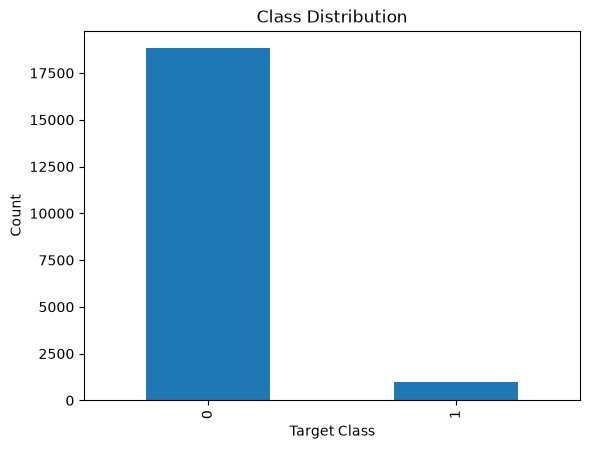

In [30]:
# Check class distribution
# df_clean['target'].value_counts()

# View class percentages
df_clean['target'].value_counts(normalize=True)  # percentage

# df_clean['target'].dtype

# Visualize class imbalance using a bar chart
df_clean['target'].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")

plt.show()

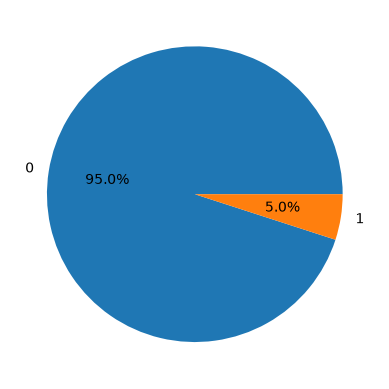

In [ ]:
# Visualize class proportions using a pie chart
df_clean['target'].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%'
)

plt.show()

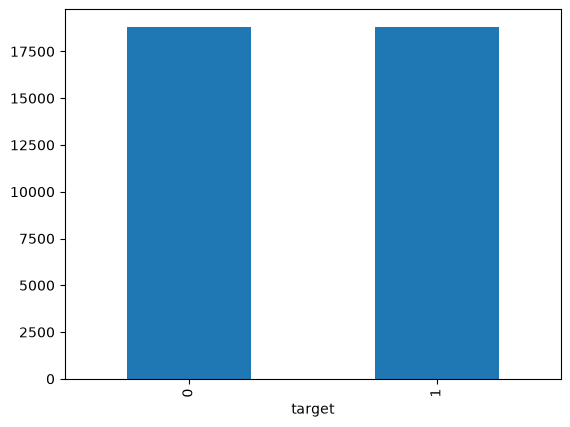

In [ ]:
# Create Random Oversampler
ros = RandomOverSampler(random_state=42)

# Resample the dataset to balance class distribution
X_res, y_res = ros.fit_resample(
    df_clean.drop('target', axis=1),
    df_clean['target']
)

# Check whether both classes are now balanced
pd.Series(y_res).value_counts().plot(kind='bar')

plt.show()  # now equal height

## Task 14 Explanation

I first checked the distribution of the `target` column using `value_counts()` and `value_counts(normalize=True)`. The results showed that class `0` was the majority class and class `1` was the minority class.

To visualize the imbalance, I created a bar chart showing the number of records in each class.

Next, I used `RandomOverSampler` from the `imbalanced-learn` library to balance the dataset. This method increases the number of minority class samples by randomly duplicating existing records until both classes have the same count.

After oversampling, I verified the result using `pd.Series(y_res).value_counts()`. The output confirmed that both classes now contain an equal number of samples.

This makes the dataset more balanced and helps machine learning models learn both classes more effectively.

## Task 15: Schema / Column Validation

The dataset may contain unnecessary columns or schema-related issues that can affect data quality and analysis. One example is the `weight_kg_duplicate` column, which contains only missing values and provides no useful information.

The objective of this task is to identify columns with a high percentage of missing values, remove unusable columns, and verify that all expected columns are present in the dataset.

In [31]:
# Check null percentage for each column
df_clean.isnull().mean()

# Identify columns with more than 50% missing values
cols_to_drop = df_clean.columns[
    df_clean.isnull().mean() > 0.5
].tolist()

cols_to_drop

# Remove low-quality columns
df_clean.drop(columns=cols_to_drop, inplace=True)

# Expected schema after cleaning
expected_cols = [
    'employee_id', 'name', 'age', 'salary', 'join_date', 'department',
    'gender', 'country', 'city', 'weight_kg', 'is_active', 'review',
    'price', 'weight_kg_duplicate', 'target'
]

# Find columns missing from the final dataset
missing = set(expected_cols) - set(df_clean.columns)

# weight_kg_duplicate was removed because it exceeded the null threshold
missing

{'weight_kg_duplicate'}

## Task 15 Explanation

I first checked the percentage of missing values in each column using `df.isnull().mean()`. This helped identify columns that contained mostly missing data.

Next, I selected columns with more than 50% missing values and stored them in a list. Since the `weight_kg_duplicate` column contained only missing values, it was identified as a useless column and removed from the dataset.

After dropping the unnecessary columns, I defined a list of expected column names and compared it with the current dataset schema to check for missing columns.

Finally, I verified the updated schema using `df.columns` to ensure that only valid and useful columns remained in the dataset.

This process improves data quality by removing unnecessary columns and ensuring a consistent dataset structure.

## All Tasks Done

After completing all 15 tasks, the final cleaned dataset is being exported as `cleaned_dataset.csv`.

In [26]:
df_clean.to_csv("cleaned_dataset.csv", index=False)